# Per-Layer Dead Residual Alpha Probe

用 sum + Ridge(alpha=100) 固定 + winsorize + 跳过 <20 天 fold。

In [3]:
# 1. 加载 + 投影 + 收益 + walk-forward + h_cache
import os, sys, time, glob, numpy as np, pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

ROOT = "/home/intern_fjq_2026/Projects/chinese-wwm-roberta"
os.chdir(ROOT); sys.path.insert(0, ROOT)
N_LAYERS = 12; DEAD_DIM = 128
# --- 从 per_file/ 加载 (用 sum, 不除以 n_posts) ---
per_dir = os.path.join(ROOT, "artifacts", "gubapost_cls", "per_file")
pf_files = sorted(glob.glob(os.path.join(per_dir, "*.parquet")))
assert pf_files, f"per_file/ 下没有文件 -> 先跑 extract_gubapost_cls.ipynb"
print(f"加载 {len(pf_files)} 个 per-file parquet...")
dfs = [pd.read_parquet(f) for f in pf_files]
pf = pd.concat(dfs, ignore_index=True); del dfs
cls = np.stack(pf["sum_cls"].values).astype(np.float32)  # sum, 不是 mean
cls_df = pf[["available_date", "symbol", "n_posts"]].copy()
print(f"CLS(sum): {cls.shape} | dates: {cls_df.available_date.min()}~{cls_df.available_date.max()}")
dead = {}
for L in range(1, N_LAYERS+1):
    dead[L] = np.stack(pf[f"sum_attn_{L:02d}"].values).astype(np.float32)  # sum
print(f"dead 128(sum): {len(dead)} layers, shape={dead[1].shape}")
del pf
# 只用已完成的年份
PROBE_YEARS = {"2020", "2021"}
_keep = cls_df["available_date"].str[:4].isin(PROBE_YEARS).values
cls = cls[_keep]; cls_df = cls_df[_keep].reset_index(drop=True)
for L in range(1, N_LAYERS+1):
    dead[L] = dead[L][_keep]
print(f"过滤后: {len(cls_df):,} stock-days")
# --- 收益 (winsorize, 前移1天) ---
rtn = pd.read_parquet("/home/intern_fjq_2026/data/RTN_daily/rtn_1d.parquet")
rtn_long = rtn.melt(id_vars="date", var_name="sym", value_name="r")
rtn_long["symbol"] = rtn_long["sym"].str.split(".").str[0]
rtn_long["date"] = pd.to_datetime(rtn_long["date"]).dt.strftime("%Y-%m-%d")
rtn_long = rtn_long.sort_values(["symbol", "date"])
rtn_long["y"] = rtn_long.groupby("symbol")["r"].shift(-1)
rtn_long = rtn_long[["date", "symbol", "y"]].dropna(subset=["y"])
rtn_long["y"] = rtn_long["y"].clip(-0.2, 0.2)
merged = cls_df[["available_date", "symbol"]].merge(
    rtn_long, left_on=["available_date", "symbol"], right_on=["date", "symbol"], how="inner")
merged = merged[["available_date", "symbol", "y"]].reset_index(drop=True)
merged["year"] = merged["available_date"].str[:4]

# 只用已完成的年份
PROBE_YEARS = {"2020", "2021"}
years = sorted(merged["year"].unique())
MIN_TEST_DAYS = 20
folds = [(years[:i], years[i]) for i in range(1, len(years))
         if (merged["year"] == years[i]).sum() >= MIN_TEST_DAYS]
print(f"walk-forward: {len(folds)} folds")
idx_all = np.arange(len(merged))
y_all = merged["y"].values.astype(np.float64)
dates_all = merged["available_date"].values
from sklearn.linear_model import Ridge
ALPHA = 100
def ric(yp, yt, d):
    ics = []
    for dt in np.unique(d):
        m = d == dt
        if m.sum() >= 10: ics.append(spearmanr(yp[m], yt[m])[0])
    return np.array(ics)
def rfp(Xtr, ytr, Xte):
    sc = StandardScaler()
    m = Ridge(alpha=ALPHA)
    m.fit(sc.fit_transform(Xtr), ytr)
    return m.predict(sc.transform(Xte))
def safe_icir(a):
    s = a.std()
    return a.mean()/s if s > 1e-6 else 0
# --- H 方向 + h_cache ---
DIRS_PATH = os.path.join(ROOT, "artifacts", "checkpoint_activation_rank", "runs", "gubapost_v1",
                         "extensions", "coverage_ablation_v1", "direction_sets.npz")
dirs_npz = np.load(DIRS_PATH)
H = cls @ dirs_npz["keep_317_complement_K64"].astype(np.float32)
L_cov = cls @ dirs_npz["keep_451_lowcov_K64"].astype(np.float32)
HL = np.hstack([H, L_cov])
print(f"H {H.shape} L {L_cov.shape}")
h_cache = {}
for fi, (tr, te) in enumerate(folds):
    ti = idx_all[merged["year"].isin(tr).values]
    ei = idx_all[(merged["year"] == te).values]
    kf = KFold(5, shuffle=False)
    oos = np.full(len(ti), np.nan)
    for a, b in kf.split(H[ti]):
        sc = StandardScaler(); m = Ridge(alpha=ALPHA)
        m.fit(sc.fit_transform(H[ti][a]), y_all[ti][a])
        oos[b] = m.predict(sc.transform(H[ti][b]))
    train_res = y_all[ti] - oos
    ypH = rfp(H[ti], y_all[ti], H[ei])
    h_cache[fi] = (train_res, y_all[ei] - ypH, dates_all[ei], ti, ei)
print("h_cache 完成")

加载 919 个 per-file parquet...
CLS(sum): (8719600, 768) | dates: 2020-01-02~2026-06-03
dead 128(sum): 12 layers, shape=(8719600, 128)
过滤后: 2,002,449 stock-days
walk-forward: 1 folds
H (2002449, 317) L (2002449, 451)
h_cache 完成


In [4]:
# 2. Per-layer probe (12 layers x [IC + residual + random])
layer_results = []
for L in range(1, N_LAYERS+1):
    t0 = time.time()
    r_L = dead[L]
    ic_f = []
    for fi, (tr, te) in enumerate(folds):
        _, _, _, ti, ei = h_cache[fi]
        yp = rfp(r_L[ti], y_all[ti], r_L[ei])
        ic_f.append(ric(yp, y_all[ei], dates_all[ei]))
    ic_L = np.concatenate(ic_f).mean()
    res_f = []
    for fi, (tr, te) in enumerate(folds):
        train_res, test_res, test_dates, ti, ei = h_cache[fi]
        rp = rfp(r_L[ti], train_res, r_L[ei])
        res_f.append(ric(rp, test_res, test_dates))
    res_ic_L = np.concatenate(res_f).mean()
    rng = np.random.default_rng(L)
    rand_means = []
    for s in range(20):
        Qr = np.linalg.qr(rng.standard_normal((768, DEAD_DIM)))[0].astype(np.float32)
        R = cls @ Qr
        rm = []
        for fi, (tr, te) in enumerate(folds):
            train_res, test_res, test_dates, ti, ei = h_cache[fi]
            rp = rfp(R[ti], train_res, R[ei])
            rm.append(ric(rp, test_res, test_dates).mean())
        rand_means.append(np.mean(rm))
    rand_m, rand_s = np.mean(rand_means), np.std(rand_means)
    sig = "YES" if res_ic_L > rand_m + 2*rand_s else ("~" if res_ic_L > rand_m else "no")
    layer_results.append({"layer":f"L{L:02d}","IC_L":ic_L,"ResidualIC":res_ic_L,
                          "Rand_mean":rand_m,"Rand_std":rand_s,"significant":sig})
    print(f"L{L:02d}: IC={ic_L:.4f} ResIC={res_ic_L:.4f} Rand={rand_m:.4f}+/-{rand_s:.4f} {sig} ({time.time()-t0:.0f}s)")
    del r_L

L01: IC=0.0012 ResIC=0.0004 Rand=-0.0075+/-0.0025 YES (246s)
L02: IC=0.0009 ResIC=-0.0022 Rand=-0.0070+/-0.0018 YES (252s)
L03: IC=-0.0002 ResIC=-0.0038 Rand=-0.0080+/-0.0021 YES (251s)
L04: IC=0.0004 ResIC=-0.0023 Rand=-0.0075+/-0.0017 YES (234s)
L05: IC=0.0004 ResIC=-0.0021 Rand=-0.0071+/-0.0024 YES (247s)
L06: IC=-0.0003 ResIC=0.0007 Rand=-0.0068+/-0.0020 YES (234s)
L07: IC=0.0004 ResIC=-0.0069 Rand=-0.0077+/-0.0024 ~ (231s)
L08: IC=-0.0005 ResIC=-0.0026 Rand=-0.0070+/-0.0018 YES (225s)
L09: IC=0.0000 ResIC=-0.0016 Rand=-0.0070+/-0.0016 YES (226s)
L10: IC=0.0001 ResIC=-0.0021 Rand=-0.0069+/-0.0023 YES (231s)
L11: IC=0.0001 ResIC=-0.0064 Rand=-0.0082+/-0.0023 ~ (217s)
L12: IC=-0.0005 ResIC=-0.0041 Rand=-0.0077+/-0.0020 ~ (213s)


=== Per-Layer Dead Residual Alpha Probe ===
layer      IC_L  ResidualIC  Rand_mean  Rand_std significant   excess
  L01  0.001229    0.000369  -0.007502  0.002521         YES 0.007871
  L02  0.000865   -0.002199  -0.006980  0.001822         YES 0.004781
  L03 -0.000227   -0.003756  -0.007975  0.002050         YES 0.004218
  L04  0.000450   -0.002264  -0.007510  0.001687         YES 0.005246
  L05  0.000377   -0.002136  -0.007136  0.002401         YES 0.005000
  L06 -0.000282    0.000725  -0.006832  0.002031         YES 0.007557
  L07  0.000429   -0.006902  -0.007705  0.002406           ~ 0.000803
  L08 -0.000490   -0.002557  -0.006984  0.001775         YES 0.004427
  L09  0.000047   -0.001592  -0.007002  0.001585         YES 0.005410
  L10  0.000097   -0.002114  -0.006937  0.002287         YES 0.004823
  L11  0.000064   -0.006365  -0.008164  0.002284           ~ 0.001799
  L12 -0.000490   -0.004086  -0.007678  0.001960           ~ 0.003593

显著层数 (ResIC > Rand+2sigma): 9/12


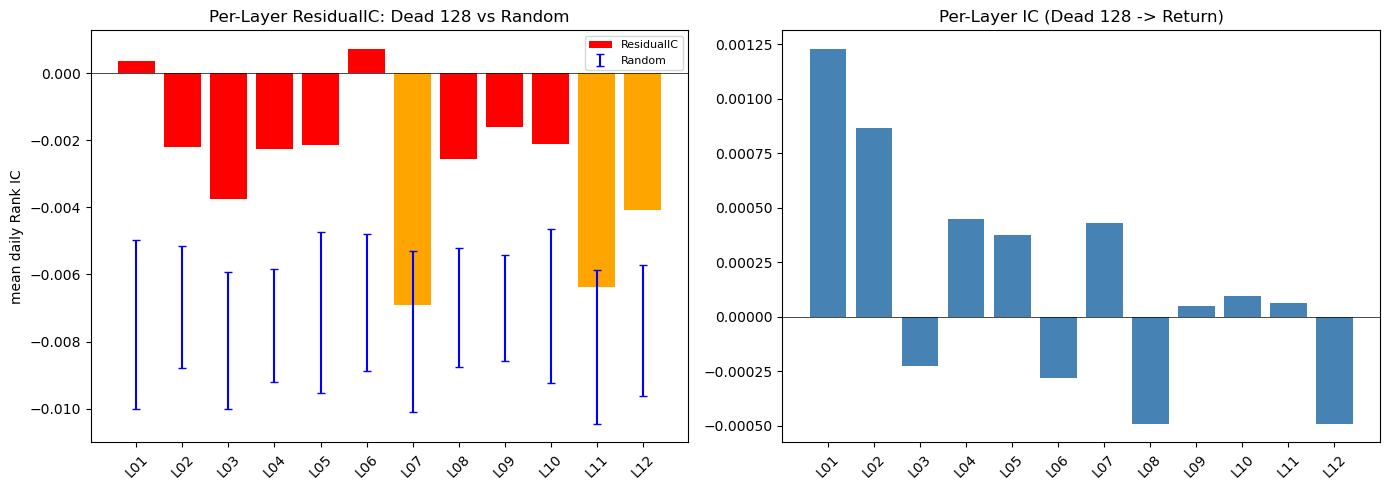

In [5]:
# 3. 汇总 + 保存 + 图
import matplotlib.pyplot as plt
res_df = pd.DataFrame(layer_results)
res_df["excess"] = res_df.ResidualIC - res_df.Rand_mean
print("=== Per-Layer Dead Residual Alpha Probe ===")
print(res_df.to_string(index=False))
n_sig = (res_df.significant == "YES").sum()
print(f"\n显著层数 (ResIC > Rand+2sigma): {n_sig}/{N_LAYERS}")
res_df.to_parquet(os.path.join(ROOT,"artifacts","gubapost_cls","dead_residual_alpha_results.parquet"), index=False)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
x = np.arange(N_LAYERS)
colors = ["red" if s=="YES" else ("orange" if s=="~" else "gray") for s in res_df.significant]
axes[0].bar(x, res_df.ResidualIC, color=colors, label="ResidualIC")
axes[0].errorbar(x, res_df.Rand_mean, yerr=res_df.Rand_std, fmt="none", ecolor="blue", capsize=3, label="Random")
axes[0].set_xticks(x); axes[0].set_xticklabels(res_df.layer, rotation=45)
axes[0].set_ylabel("mean daily Rank IC"); axes[0].set_title("Per-Layer ResidualIC: Dead 128 vs Random")
axes[0].axhline(0,color="black",lw=0.5); axes[0].legend(fontsize=8)
axes[1].bar(x, res_df.IC_L, color="steelblue")
axes[1].set_xticks(x); axes[1].set_xticklabels(res_df.layer, rotation=45)
axes[1].set_title("Per-Layer IC (Dead 128 -> Return)"); axes[1].axhline(0,color="black",lw=0.5)
plt.tight_layout(); plt.show()